# Notebook 01: Data Collection & Exploratory Data Analysis

**Project:** Intelligent Code Review Assistant  

---

## Objectives
- Download the CodeSearchNet dataset (Python subset) via HuggingFace
- Collect labeled bug data from GitHub using PyGitHub
- Load additional labeled datasets (Devign, CodeXGLUE)
- Combine and label all sources into a unified dataset
- Perform Exploratory Data Analysis (EDA)
- Save the final processed dataset for use in Notebook 02

---

## Pipeline Overview
```
Raw Sources -> CodeSearchNet + GitHub PRs + Devign + CodeXGLUE
     ↓
Combine & Label (0 = clean, 1 = buggy)
     ↓
Clean & Filter
     ↓
EDA & Visualization
     ↓
Save -> data/processed/labeled_dataset.csv
```

In [1]:
# Install all required libraries for this notebook
# Run this cell once. Restart kernel if needed after installation.

# !pip install datasets transformers PyGithub pandas numpy matplotlib seaborn scikit-learn tqdm -q

---
## Section 1: Import Libraries

In [14]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import re
import time
import json
import warnings
warnings.filterwarnings("ignore")

# ── Data handling ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── HuggingFace ────────────────────────────────────────────────────────────────
from datasets import load_dataset, load_from_disk, concatenate_datasets

# ── GitHub API ─────────────────────────────────────────────────────────────────
from github import Github, RateLimitExceededException

from dotenv import load_dotenv

# ── Progress bar ───────────────────────────────────────────────────────────────
from tqdm.notebook import tqdm

# ── Visualization ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Styling ────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

print("All libraries imported successfully.")

All libraries imported successfully.


### Directory setup

In [15]:
# Create the folder structure needed across the whole project.
# 'exist_ok=True' means no error is raised if the folder already exists.

dirs = [
    "../data/raw",
    "../data/processed",
    "../reports/figures"
]

for d in dirs:
    os.makedirs(d, exist_ok=True)

print("Directory structure ready:")
for d in dirs:
    print(f"   {d}/")

Directory structure ready:
   ../data/raw/
   ../data/processed/
   ../reports/figures/


In [16]:
# Optional but recommended — avoids rate limit warnings on HuggingFace downloads.
# Get a free token at: https://huggingface.co/settings/tokens
# Add this line to your .env file: HF_TOKEN=hf_xxxxxxxxxxxxxxxx

from huggingface_hub import login
import os

hf_token = os.getenv("HF_TOKEN")
if hf_token:
    login(token=hf_token, add_to_git_credential=False)
    print("HuggingFace authenticated.")
else:
    print("No HF_TOKEN found — downloads will work but may be slower.")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HuggingFace authenticated.


---
## Section 2: Download CodeSearchNet Dataset (HuggingFace)

CodeSearchNet is a large benchmark dataset of open-source functions paired with docstrings, collected from GitHub. Here the **Python subset** is used (~500K functions) as our primary source of **clean code** (label = 0).

- Source: https://huggingface.co/datasets/code_search_net
- Paper: Husain et al. (2019) — "CodeSearchNet Challenge"
- Columns use: `func_code_string`, `func_documentation_string`, `repository_name`

In [17]:
# Load the Python split of CodeSearchNet from HuggingFace Hub.
# This downloads ~1GB on first run and caches it automatically.
# Subsequent runs load from cache — no re-download needed.

print("Downloading CodeSearchNet (Python)...")
csn_dataset = load_dataset("code_search_net", "python")   

print("\nDataset loaded.")
print(csn_dataset)


Dataset loaded.
DatasetDict({
    train: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
        num_rows: 412178
    })
    test: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
        num_rows: 22176
    })
    validation: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
        num_rows: 23107
    })
})


### Inspect CodeSearchNet structure

In [18]:
# Look at the keys (columns) available in each sample.

sample = csn_dataset["train"][0]

print("Available columns:")
for key, value in sample.items():
    preview = str(value)[:80].replace("\n", " ")
    print(f"  {key:35s} -> {preview}")

Available columns:
  repository_name                     -> mjirik/imcut
  func_path_in_repository             -> imcut/pycut.py
  func_name                           -> ImageGraphCut.__msgc_step3_discontinuity_localization
  whole_func_string                   -> def __msgc_step3_discontinuity_localization(self):         """         Estimate 
  language                            -> python
  func_code_string                    -> def __msgc_step3_discontinuity_localization(self):         """         Estimate 
  func_code_tokens                    -> ['def', '__msgc_step3_discontinuity_localization', '(', 'self', ')', ':', 'impor
  func_documentation_string           -> Estimate discontinuity in basis of low resolution image segmentation.         :r
  func_documentation_tokens           -> ['Estimate', 'discontinuity', 'in', 'basis', 'of', 'low', 'resolution', 'image',
  split_name                          -> train
  func_code_url                       -> https://github.com/mjirik/imcu

### Extract and label CodeSearchNet

In [19]:
# CodeSearchNet functions are treated as CLEAN code (label = 0).
# A manageable sample is taken from the train split to keep training fast.
# Adjust SAMPLE_SIZE based on available RAM and GPU memory.

SAMPLE_SIZE = 15000  # increase to 50000 if there is more compute

csn_train = csn_dataset["train"]

csn_df = pd.DataFrame({
    "code":     csn_train["func_code_string"][:SAMPLE_SIZE],
    "docstring":csn_train["func_documentation_string"][:SAMPLE_SIZE],
    "repo":     csn_train["repository_name"][:SAMPLE_SIZE],
    "language": ["python"] * SAMPLE_SIZE,
    "label":    [0] * SAMPLE_SIZE,       # 0 = clean
    "source":   ["codesearchnet"] * SAMPLE_SIZE
})

# Drop rows where the function body is missing or just whitespace
csn_df = csn_df[csn_df["code"].str.strip().str.len() > 0]

print(f"CodeSearchNet samples loaded: {len(csn_df):,}")
print(f"   Label distribution:\n{csn_df['label'].value_counts().to_string()}")
csn_df.head(5)

CodeSearchNet samples loaded: 15,000
   Label distribution:
label
0    15000


,code,docstring,repo,language,label,source
0,def __msgc_step3_discontinuity_localization(se...,Estimate discontinuity in basis of low resolut...,mjirik/imcut,python,0,codesearchnet
1,"def __multiscale_gc_lo2hi_run(self): # , pyed...",Run Graph-Cut segmentation with refinement of ...,mjirik/imcut,python,0,codesearchnet
2,"def __multiscale_gc_hi2lo_run(self): # , pyed...",Run Graph-Cut segmentation with simplifiyng of...,mjirik/imcut,python,0,codesearchnet
3,"def __ordered_values_by_indexes(self, data, in...",Return values (intensities) by indexes.\n\n ...,mjirik/imcut,python,0,codesearchnet
4,"def __hi2lo_multiscale_indexes(self, mask, ori...",Function computes multiscale indexes of ndarra...,mjirik/imcut,python,0,codesearchnet


### Save CodeSearchNet to disk

In [20]:
# Save the raw CodeSearchNet extract so not re-download if kernel restarts.

csn_df.to_csv("../data/raw/codesearchnet_python.csv", index=False)
print("Saved -> ../data/raw/codesearchnet_python.csv")

Saved -> ../data/raw/codesearchnet_python.csv


---
## Section 3: Load Additional Labeled Datasets

These datasets provide **pre-labeled buggy code** (label = 1) so don't have
to label everything manually.

| Dataset | Language | Size | Task |
|---|---|---|---|
| Devign | C | ~27K | Vulnerability detection (0/1) |
| CodeXGLUE Defect Detection | C | ~27K | Same as Devign, standard split |

These are used as our primary source of buggy samples.

In [21]:
# Devign: a widely-cited dataset of C functions labeled as vulnerable (1) or clean (0).
# Source: https://huggingface.co/datasets/google/code_x_glue_cc_defect_detection

print("Loading Devign dataset...")

devign = load_dataset("google/code_x_glue_cc_defect_detection")

print(f"\nDevign loaded.")
print(devign)
print(f"\nSample columns: {list(devign['train'][0].keys())}")

Loading Devign dataset...

Devign loaded.
DatasetDict({
    train: Dataset({
        features: ['id', 'func', 'target', 'project', 'commit_id'],
        num_rows: 21854
    })
    validation: Dataset({
        features: ['id', 'func', 'target', 'project', 'commit_id'],
        num_rows: 2732
    })
    test: Dataset({
        features: ['id', 'func', 'target', 'project', 'commit_id'],
        num_rows: 2732
    })
})

Sample columns: ['id', 'func', 'target', 'project', 'commit_id']


### Extract Devign into DataFrame

In [22]:
# Combine all Devign splits (train + validation + test) for maximum coverage.
# IMPORTANT: Devign's 'target' column returns Python booleans (True/False),
# not integers. We explicitly cast to int to ensure label consistency (0/1)
# across all data sources. Without this, pd.concat creates a mixed-type
# label column where (label == 0) and (label == 1) return all False.

devign_frames = []

for split in ["train", "validation", "test"]:
    split_data = devign[split]
    df = pd.DataFrame({
        "code":      split_data["func"],
        "docstring": [""] * len(split_data),
        "repo":      ["devign"] * len(split_data),
        "language":  ["c"] * len(split_data),
        "label":     [int(x) for x in split_data["target"]],  # cast bool → int
        "source":    ["devign"] * len(split_data)
    })
    devign_frames.append(df)

devign_df = pd.concat(devign_frames, ignore_index=True)

# Verify labels are now proper integers
assert devign_df["label"].dtype in ["int32", "int64"], "Label dtype error!"
assert set(devign_df["label"].unique()) == {0, 1}, "Unexpected label values!"

print(f"Devign samples: {len(devign_df):,}")
print(f"   dtype: {devign_df['label'].dtype}")
print(f"   Label distribution:")
print(devign_df["label"].value_counts().to_string())
devign_df.head(5)

Devign samples: 27,318
   dtype: int64
   Label distribution:
label
0    14858
1    12460


,code,docstring,repo,language,label,source
0,static av_cold int vdadec_init(AVCodecContext ...,,devign,c,0,devign
1,static int transcode(AVFormatContext **output_...,,devign,c,0,devign
2,"static void v4l2_free_buffer(void *opaque, uin...",,devign,c,0,devign
3,"int av_opencl_buffer_write(cl_mem dst_cl_buf, ...",,devign,c,0,devign
4,"static int r3d_read_rdvo(AVFormatContext *s, A...",,devign,c,1,devign


### Load CodeXGLUE defect detection

In [23]:
# CodeXGLUE Defect Detection is Microsoft's benchmark built on top of Devign.
# It uses the same data but with a standardized train/val/test split.
# It gives us a second clean reference and confirms label consistency.

print("Loading CodeXGLUE Defect Detection...")

try:
    codexglue = load_dataset("microsoft/codexglue_defect_detection")
    print(f"\nCodeXGLUE loaded.")
    print(codexglue)

    codexglue_df = pd.DataFrame({
        "code":     codexglue["train"]["func"],
        "docstring": [""] * len(codexglue["train"]),
        "repo":     ["codexglue"] * len(codexglue["train"]),
        "language": ["c"] * len(codexglue["train"]),
        "label":    codexglue["train"]["target"],
        "source":   ["codexglue"] * len(codexglue["train"])
    })

    print(f"\n   Samples loaded: {len(codexglue_df):,}")
    print(f"   Label distribution:\n{codexglue_df['label'].value_counts().to_string()}")

except Exception as e:
    # CodeXGLUE may overlap heavily with Devign — safe to skip if unavailable
    print(f"Could not load CodeXGLUE: {e}")
    print("Continuing without it — Devign covers the same data.")
    codexglue_df = pd.DataFrame(columns=["code","docstring","repo","language","label","source"])

Loading CodeXGLUE Defect Detection...
Could not load CodeXGLUE: Dataset 'microsoft/codexglue_defect_detection' doesn't exist on the Hub or cannot be accessed.
Continuing without it — Devign covers the same data.


---
## Section 4: Collect Labeled Bug Data from GitHub (PyGitHub)

GitHub REST API is used to:
1. Search for popular Python repositories
2. Find **closed Pull Requests** that fixed bugs (PRs linked to issues labeled "bug")
3. Extract the **before** (buggy) version of changed files from the diff/patch
4. Label these as buggy (label = 1)

**Why PRs instead of Issues?**
PRs contain the actual code diff — It can be extracted what the buggy code looked like before the fix. Issues alone only describe the problem in text.

> Need a free GitHub Personal Access Token.
> Get one at: https://github.com/settings/tokens -> "Generate new token (classic)"
> -> Select scope: `public_repo` only -> Copy the token below.

In [24]:
# Paste GitHub Personal Access Token here.

# Load GitHub token securely from .env file

from dotenv import load_dotenv
from github import Github, Auth
import os

# Load environment variables from .env
load_dotenv()


# Read GitHub token
GITHUB_TOKEN = os.getenv("GITHUB_TOKEN")

# New authentication method
auth = Auth.Token(GITHUB_TOKEN)

# Create GitHub object
g = Github(auth=auth)

# Verify authentication — this shows rate limit (5000/hr when authenticated)
rate = g.get_rate_limit()
print(f"GitHub authenticated.")
# Core API limit
print(
    f"Core requests remaining : "
    f"{rate.rate.remaining} / {rate.rate.limit}"
)

# Search API limit
search_rate = rate.resources.search

print(
    f"Search requests remaining: "
    f"{search_rate.remaining} / {search_rate.limit}"
)

GitHub authenticated.
Core requests remaining : 5000 / 5000
Search requests remaining: 30 / 30


### Helper functions for patch extraction

In [25]:
# These functions parse a git diff patch to extract the code that was removed (buggy) and the code that was added (fixed).
#
# In a git diff:
#   Lines starting with "-" = lines that were REMOVED (the buggy code)
#   Lines starting with "+" = lines that were ADDED  (the fixed code)
#   Lines starting with " " = context lines (unchanged)

def extract_buggy_code(patch: str) -> str:
    """Return the removed lines from a diff patch (the code before the fix)."""
    if not patch:
        return ""
    lines = []
    for line in patch.split("\n"):
        # Lines starting with "-" are deletions; skip the "---" file header
        if line.startswith("-") and not line.startswith("---"):
            lines.append(line[1:])   # strip the leading "-"
    return "\n".join(lines)


def extract_fixed_code(patch: str) -> str:
    """Return the added lines from a diff patch (the code after the fix)."""
    if not patch:
        return ""
    lines = []
    for line in patch.split("\n"):
        # Lines starting with "+" are additions; skip the "+++" file header
        if line.startswith("+") and not line.startswith("+++"):
            lines.append(line[1:])
    return "\n".join(lines)


def is_meaningful_patch(patch: str, min_del: int = 2, max_del: int = 80) -> bool:
    """
    Filter out trivial patches (1-line whitespace fixes) and
    massive patches (entire file rewrites).
    We count deleted lines as a proxy for how much buggy code exists.
    """
    if not patch:
        return False
    deleted = sum(1 for l in patch.split("\n")
                  if l.startswith("-") and not l.startswith("---"))
    return min_del <= deleted <= max_del


print("Patch helper functions defined.")

Patch helper functions defined.


### GitHub scraper function

In [26]:
def is_meaningful_patch(patch: str, min_del: int = 1, max_del: int = 150) -> bool:
    """
    Filter out empty patches and unrealistically massive diffs.
    Lowered min_del to 1 so single-line real bug fixes aren't discarded.
    Raised max_del to 150 to capture larger functions.
    """
    if not patch:
        return False
    deleted = sum(
        1 for line in patch.split("\n")
        if line.startswith("-") and not line.startswith("---")
    )
    return min_del <= deleted <= max_del


def collect_github_bug_fixes(
    repos_to_search: int = 25,
    max_prs_per_repo: int = 50,
    sleep_between_repos: float = 1.5
) -> pd.DataFrame:
    """
    Search GitHub for Python repos, find merged PRs that fixed bugs,
    extract the buggy (before-fix) code from the diff patch.

    Two collection strategies used in order:
      1. Issues labeled 'bug' / 'bugfix' / 'fix' / 'defect' -> linked PR diff
      2. Fallback: scan recent merged PRs whose title contains fix/bug keywords

    Parameters
    ----------
    repos_to_search    : number of repos to scan
    max_prs_per_repo   : max bug-fix PRs to collect per repo
    sleep_between_repos: seconds to pause between repos (rate limit safety)
    """

    records = []

    # Bug-related issue labels to try — different repos use different conventions
    BUG_LABELS = ["bug", "bugfix", "fix", "defect", "Bug", "bug fix"]

    # Keywords to match against PR titles as a fallback
    BUG_KEYWORDS = ["fix", "bug", "patch", "error", "issue", "crash", "fail", "broken"]

    query = "language:python stars:>200"
    print(f"Searching repos: '{query}'")
    repos = g.search_repositories(query=query, sort="stars", order="desc")
    repo_list = list(repos[:repos_to_search])
    print(f"Found {len(repo_list)} repos to scan.\n")

    for repo in tqdm(repo_list, desc="Scanning repos"):
        try:
            repo_name = repo.full_name
            pr_count = 0

            # ── Strategy 1: Issues with bug-related labels ─────────────────────
            for label_name in BUG_LABELS:
                if pr_count >= max_prs_per_repo:
                    break
                try:
                    bug_issues = repo.get_issues(
                        state="closed",
                        labels=[label_name],
                        sort="updated",
                        direction="desc"
                    )
                    for issue in bug_issues:
                        if pr_count >= max_prs_per_repo:
                            break
                        if not issue.pull_request:
                            continue
                        try:
                            pr = issue.as_pull_request()
                            if not pr.merged:
                                continue
                            for changed_file in pr.get_files():
                                if not changed_file.filename.endswith(".py"):
                                    continue
                                patch = changed_file.patch
                                if not is_meaningful_patch(patch):
                                    continue
                                buggy_code = extract_buggy_code(patch)
                                if len(buggy_code.strip()) < 30:
                                    continue
                                records.append({
                                    "code":      buggy_code,
                                    "docstring": "",
                                    "repo":      repo_name,
                                    "language":  "python",
                                    "label":     1,
                                    "source":    "github_prs",
                                    "pr_title":  pr.title,
                                    "file":      changed_file.filename
                                })
                                pr_count += 1
                        except RateLimitExceededException:
                            print("\nRate limit — sleeping 60s...")
                            time.sleep(60)
                        except Exception:
                            continue
                except Exception:
                    continue   # label doesn't exist in this repo — skip

            # ── Strategy 2: Fallback — scan PR titles for bug keywords ──────────
            if pr_count < 5:   # only use fallback if Strategy 1 gave very little
                try:
                    pulls = repo.get_pulls(
                        state="closed",
                        sort="updated",
                        direction="desc"
                    )
                    for pr in list(pulls)[:100]:
                        if pr_count >= max_prs_per_repo:
                            break
                        if not pr.merged:
                            continue
                        title_lower = pr.title.lower()
                        if not any(kw in title_lower for kw in BUG_KEYWORDS):
                            continue
                        try:
                            for changed_file in pr.get_files():
                                if not changed_file.filename.endswith(".py"):
                                    continue
                                patch = changed_file.patch
                                if not is_meaningful_patch(patch):
                                    continue
                                buggy_code = extract_buggy_code(patch)
                                if len(buggy_code.strip()) < 30:
                                    continue
                                records.append({
                                    "code":      buggy_code,
                                    "docstring": "",
                                    "repo":      repo_name,
                                    "language":  "python",
                                    "label":     1,
                                    "source":    "github_prs",
                                    "pr_title":  pr.title,
                                    "file":      changed_file.filename
                                })
                                pr_count += 1
                        except RateLimitExceededException:
                            print("\nRate limit — sleeping 60s...")
                            time.sleep(60)
                        except Exception:
                            continue
                except Exception:
                    pass

            time.sleep(sleep_between_repos)

        except RateLimitExceededException:
            print("\nRate limit on repo search — sleeping 60s...")
            time.sleep(60)
            continue
        except Exception as e:
            print(f"\nSkipped {repo.full_name}: {e}")
            continue

    df = pd.DataFrame(records)
    print(f"\nGitHub collection complete: {len(df):,} buggy samples")
    if len(df) > 0:
        print(f"   From {df['repo'].nunique()} unique repositories")
    return df


print("Scraper function defined.")

Scraper function defined.


 ### Run the GitHub scraper

In [27]:
# Run with increased repo count and PR limit to collect enough Python bug samples.
# Expected yield: 200–800 samples depending on how many repos use the "bug" label.
# This takes 5-10 minutes. Let it run — don't interrupt.

import pandas as pd
import time

from tqdm.notebook import tqdm
from github import Github
from github.GithubException import RateLimitExceededException

github_df = collect_github_bug_fixes(
    repos_to_search   = 5,   # scan 5 repos
    max_prs_per_repo  = 8,   # up to 8 bug-fix PRs each
    sleep_between_repos = 1.0
)

# Save results
github_df.to_csv("../data/raw/github_bug_fixes.csv", index=False)

print(f"\nSaved -> ../data/raw/github_bug_fixes.csv")

# Quick sanity check
print(f"\nLabel distribution:")
print(github_df["label"].value_counts().to_string())

print(f"\nTop contributing repos:")
print(github_df["repo"].value_counts().head(10).to_string())

github_df.head(5)

Searching repos: 'language:python stars:>200'
Found 5 repos to scan.



Scanning repos:   0%|          | 0/5 [00:00<?, ?it/s]


GitHub collection complete: 8 buggy samples
   From 1 unique repositories

Saved -> ../data/raw/github_bug_fixes.csv

Label distribution:
label
1    8

Top contributing repos:
repo
TheAlgorithms/Python    8


,code,docstring,repo,language,label,source,pr_title,file
0,A interface to define search problems. The...,,TheAlgorithms/Python,python,1,github_prs,Fixes LGTM issues,searches/hill_climbing.py
1,# Implementing Newton Raphson method in Python...,,TheAlgorithms/Python,python,1,github_prs,Bug Fixed in newton_raphson_method.py,arithmetic_analysis/newton_raphson_method.py
2,>>> from maths.prime_check import prime_ch...,,TheAlgorithms/Python,python,1,github_prs,fix: test failures,maths/miller_rabin.py
3,self.assertFalse(\n is_prim...,,TheAlgorithms/Python,python,1,github_prs,fix: test failures,maths/prime_check.py
4,import statistics\r\n\r\n\r\ndef mode(input_li...,,TheAlgorithms/Python,python,1,github_prs,Mistake in maths/average_mode.py fixed.,maths/average_mode.py


### Standardize GitHub DataFrame columns

In [28]:
# Keep only the columns that match our unified schema before merging.
# The 'pr_title' and 'file' columns were useful for inspection above but are not needed in the final training dataset.

github_clean_df = github_df[[
    "code", "docstring", "repo", "language", "label", "source"
]].copy()

print(f"GitHub DataFrame standardized.")
print(f"   Shape: {github_clean_df.shape}")
print(f"   Label distribution:\n{github_clean_df['label'].value_counts().to_string()}")

GitHub DataFrame standardized.
   Shape: (8, 6)
   Label distribution:
label
1    8


---
## Section 5: Combine All Sources & Build Unified Dataset

Now merge:
| Source | Label | Type |
|---|---|---|
| CodeSearchNet (Python) | 0 | Clean functions |
| Devign | 0 / 1 | C vulnerability dataset |
| CodeXGLUE | 0 / 1 | C defect detection |
| GitHub PRs | 1 | Python bug-fix diffs |

Final schema: `code | docstring | repo | language | label | source`

### Merge all DataFrames

In [29]:
# Concatenate all source DataFrames into one unified DataFrame.
# ignore_index=True resets the row index so there are no duplicate indices.

all_frames = [csn_df, devign_df, github_clean_df]

# Only add CodeXGLUE if it loaded successfully
if len(codexglue_df) > 0:
    all_frames.append(codexglue_df)

combined_df = pd.concat(all_frames, ignore_index=True)

print(f"Combined dataset shape: {combined_df.shape}")
print(f"\nSamples per source:")
print(combined_df["source"].value_counts().to_string())
print(f"\nOverall label distribution:")
print(combined_df["label"].value_counts().to_string())

Combined dataset shape: (42326, 6)

Samples per source:
source
devign           27318
codesearchnet    15000
github_prs           8

Overall label distribution:
label
0    29858
1    12468


### Clean and filter the combined dataset

In [30]:
# ── Step 1: Drop rows with missing or empty code ───────────────────────────────
before = len(combined_df)
combined_df = combined_df.dropna(subset=["code"])
combined_df = combined_df[combined_df["code"].str.strip().str.len() > 0]
print(f"After dropping empty code: {len(combined_df):,}  (removed {before - len(combined_df):,})")

# ── Step 2: Drop code that is too short to be meaningful ──────────────────────
MIN_CODE_LENGTH = 40   # characters — anything shorter is likely a stub
before = len(combined_df)
combined_df = combined_df[combined_df["code"].str.len() >= MIN_CODE_LENGTH]
print(f"After min-length filter ({MIN_CODE_LENGTH} chars): {len(combined_df):,}  (removed {before - len(combined_df):,})")

# ── Step 3: Drop code that is unrealistically long ────────────────────────────
MAX_CODE_LENGTH = 5000  # characters — avoids entire-file samples
before = len(combined_df)
combined_df = combined_df[combined_df["code"].str.len() <= MAX_CODE_LENGTH]
print(f"After max-length filter ({MAX_CODE_LENGTH} chars): {len(combined_df):,}  (removed {before - len(combined_df):,})")

# ── Step 4: Remove exact duplicate code strings ───────────────────────────────
before = len(combined_df)
combined_df = combined_df.drop_duplicates(subset=["code"])
print(f"After deduplication: {len(combined_df):,}  (removed {before - len(combined_df):,})")

# ── Step 5: Reset index ───────────────────────────────────────────────────────
combined_df = combined_df.reset_index(drop=True)
combined_df["id"] = combined_df.index

print(f"\nFinal cleaned dataset: {len(combined_df):,} samples")
print(f"\nFinal label distribution:")
print(combined_df["label"].value_counts().to_string())

After dropping empty code: 42,326  (removed 0)
After min-length filter (40 chars): 42,313  (removed 13)
After max-length filter (5000 chars): 39,713  (removed 2,600)
After deduplication: 39,656  (removed 57)

Final cleaned dataset: 39,656 samples

Final label distribution:
label
0    28372
1    11284


### Add derived features for EDA

In [31]:
# Computed columns for EDA analysis — not fed into the model directly.

combined_df["code_length"]   = combined_df["code"].str.len()
combined_df["line_count"]    = combined_df["code"].str.count("\n") + 1
combined_df["word_count"]    = combined_df["code"].str.split().str.len()
combined_df["has_docstring"] = combined_df["docstring"].str.strip().str.len() > 0

# Verify label column is all integers before EDA — catches any lingering type issues
combined_df["label"] = combined_df["label"].astype(int)

print("Derived features added.")
print(combined_df[["code_length", "line_count", "word_count"]].describe().round(1))
print(f"\nSamples with docstring : {combined_df['has_docstring'].sum():,}")
print(f"Samples without        : {(~combined_df['has_docstring']).sum():,}")

# Final label type confirmation
print(f"\nLabel dtype  : {combined_df['label'].dtype}")
print(f"Label values : {sorted(combined_df['label'].unique())}")

Derived features added.
       code_length  line_count  word_count
count      39656.0     39656.0     39656.0
mean        1097.9        54.5       106.1
std         1019.6        56.7       100.5
min           40.0         2.0         3.0
25%          373.0        16.0        36.0
50%          724.0        32.0        70.0
75%         1455.0        72.0       141.0
max         4999.0       396.0       768.0

Samples with docstring : 14,694
Samples without        : 24,962

Label dtype  : int64
Label values : [np.int64(0), np.int64(1)]


---
## Section 6: Exploratory Data Analysis (EDA)

We visualize the dataset to:
- Check label balance (important for model training)
- Understand code length distributions
- Compare clean vs buggy code characteristics
- Inspect samples manually

### Plot 1: Label distribution

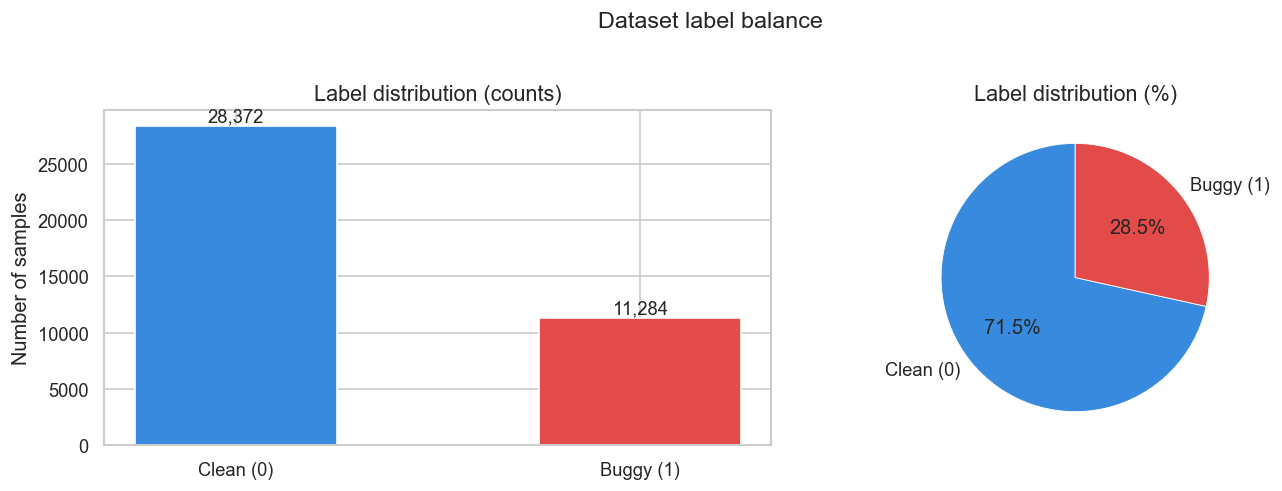


Imbalance ratio (clean:buggy) = 2.5:1
Note this ratio — we will handle imbalance during training (weighted loss).


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: count bar chart ──────────────────────────────────────────────────────
label_counts = combined_df["label"].value_counts()
colors = ["#378ADD", "#E24B4A"]
bars = axes[0].bar(["Clean (0)", "Buggy (1)"], label_counts.values, color=colors, width=0.5)
axes[0].set_title("Label distribution (counts)", fontsize=13)
axes[0].set_ylabel("Number of samples")
for bar, count in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{count:,}", ha="center", va="bottom", fontsize=11)

# ── Right: percentage pie chart ───────────────────────────────────────────────
axes[1].pie(
    label_counts.values,
    labels=["Clean (0)", "Buggy (1)"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"linewidth": 0.5, "edgecolor": "white"}
)
axes[1].set_title("Label distribution (%)", fontsize=13)

plt.suptitle("Dataset label balance", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/01_label_distribution.png", bbox_inches="tight")
plt.show()

imbalance_ratio = label_counts[0] / label_counts[1]
print(f"\nImbalance ratio (clean:buggy) = {imbalance_ratio:.1f}:1")
print("Note this ratio — we will handle imbalance during training (weighted loss).")

### Plot 2: Samples per source

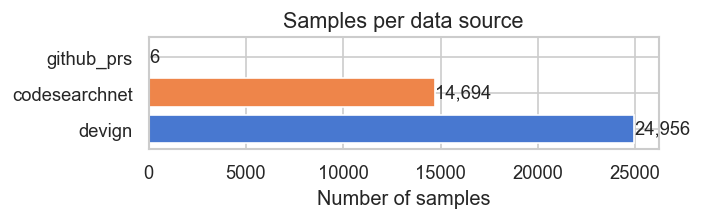

In [33]:
fig, ax = plt.subplots(figsize=(6, 2))

source_counts = combined_df["source"].value_counts()
palette = sns.color_palette("muted", len(source_counts))
bars = ax.barh(source_counts.index, source_counts.values, color=palette)

ax.set_xlabel("Number of samples")
ax.set_title("Samples per data source", fontsize=13)

for bar, val in zip(bars, source_counts.values):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=11)

plt.tight_layout()
plt.savefig("../reports/figures/02_samples_per_source.png", bbox_inches="tight")
plt.show()

### Plot 3: Code length distribution by label

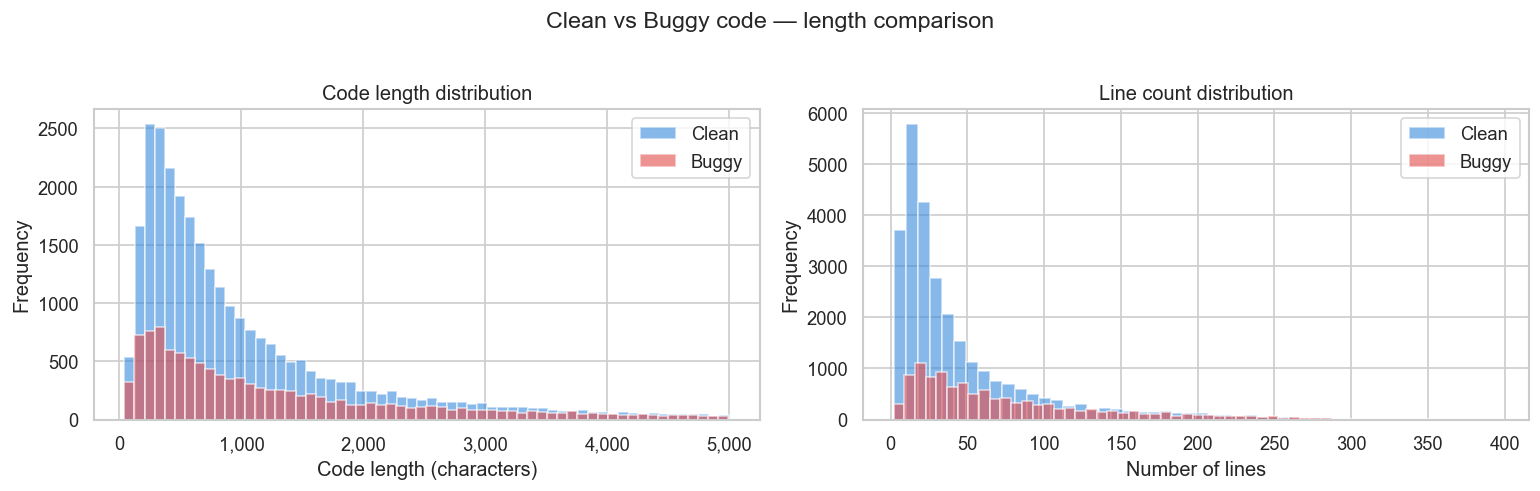

Summary statistics by label:
      code_length                line_count              word_count         \
             mean median     std       mean median   std       mean median   
label                                                                        
0          1025.1  681.0   954.9       46.3   26.0  51.3       99.2   66.0   
1          1281.1  880.0  1146.3       75.2   54.0  63.8      123.3   83.0   

              
         std  
label         
0       94.4  
1      112.6  


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

clean_df = combined_df[combined_df["label"] == 0]
buggy_df = combined_df[combined_df["label"] == 1]

# ── Left: character length ────────────────────────────────────────────────────
axes[0].hist(clean_df["code_length"], bins=60, alpha=0.6, label="Clean", color="#378ADD")
axes[0].hist(buggy_df["code_length"], bins=60, alpha=0.6, label="Buggy", color="#E24B4A")
axes[0].set_xlabel("Code length (characters)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Code length distribution")
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# ── Right: line count ─────────────────────────────────────────────────────────
axes[1].hist(clean_df["line_count"], bins=50, alpha=0.6, label="Clean", color="#378ADD")
axes[1].hist(buggy_df["line_count"], bins=50, alpha=0.6, label="Buggy", color="#E24B4A")
axes[1].set_xlabel("Number of lines")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Line count distribution")
axes[1].legend()

plt.suptitle("Clean vs Buggy code — length comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/03_code_length_distribution.png", bbox_inches="tight")
plt.show()

print("Summary statistics by label:")
print(combined_df.groupby("label")[["code_length","line_count","word_count"]]
      .agg(["mean","median","std"]).round(1))

### Plot 4: Language breakdown

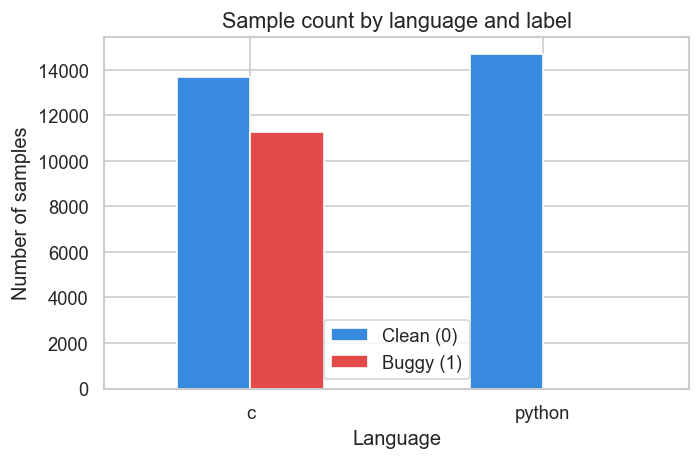

In [35]:
fig, ax = plt.subplots(figsize=(6, 4))

lang_label = combined_df.groupby(["language","label"]).size().unstack(fill_value=0)
lang_label.plot(
    kind="bar",
    ax=ax,
    color=["#378ADD", "#E24B4A"],
    width=0.5,
    edgecolor="white"
)
ax.set_xlabel("Language")
ax.set_ylabel("Number of samples")
ax.set_title("Sample count by language and label", fontsize=13)
ax.legend(["Clean (0)", "Buggy (1)"])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("../reports/figures/04_language_breakdown.png", bbox_inches="tight")
plt.show()

### Plot 5: Code length boxplot (clean vs buggy)

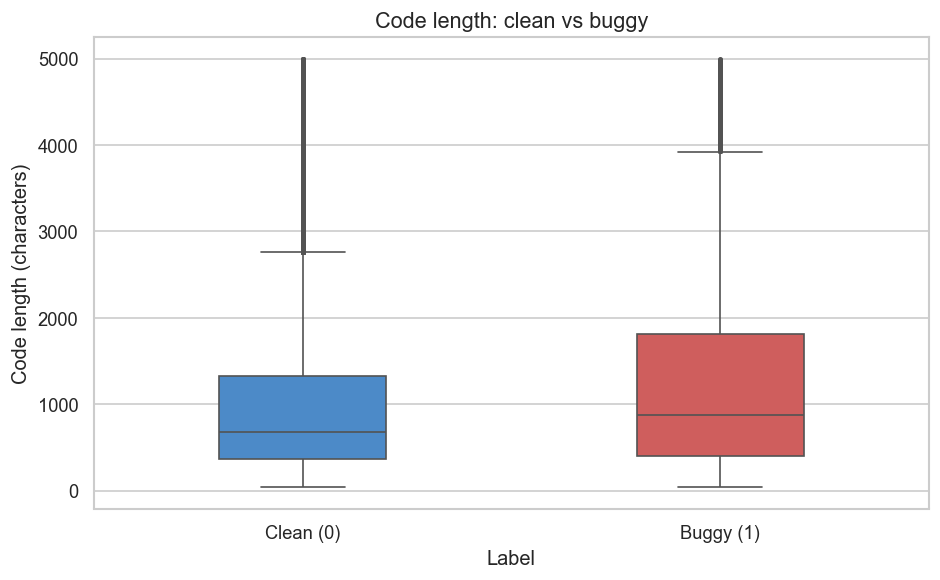

In [36]:
# Convert labels to string
combined_df["label"] = combined_df["label"].astype(str)

# Create figure
fig, ax = plt.subplots(figsize=(8, 5))

# Create boxplot
sns.boxplot(
    data=combined_df,
    x="label",
    y="code_length",
    palette={
        "0": "#378ADD",
        "1": "#E24B4A"
    },
    width=0.4,
    fliersize=2,
    ax=ax
)

# Axis labels
ax.set_xticklabels(["Clean (0)", "Buggy (1)"])
ax.set_xlabel("Label")
ax.set_ylabel("Code length (characters)")
ax.set_title("Code length: clean vs buggy", fontsize=13)

# Layout
plt.tight_layout()

# Save figure
plt.savefig(
    "../reports/figures/05_boxplot_code_length.png",
    bbox_inches="tight"
)

# Display
plt.show()

### Plot 6: Correlation heatmap of numeric features

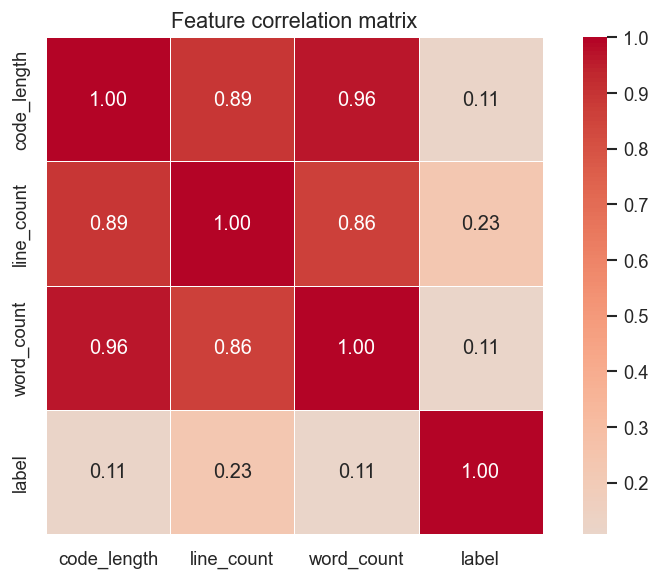

In [37]:
fig, ax = plt.subplots(figsize=(7, 5))

numeric_cols = ["code_length", "line_count", "word_count", "label"]
corr = combined_df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
    square=True
)
ax.set_title("Feature correlation matrix", fontsize=13)

plt.tight_layout()
plt.savefig("../reports/figures/06_correlation_heatmap.png", bbox_inches="tight")
plt.show()

### Manual sample inspection

In [38]:
# Always read a few raw samples manually.
# This catches data quality issues (garbled diffs, non-code text, etc.) that statistics and plots can't reveal.

def show_samples(df, label, n=3):

    # Convert label to string because dataframe labels are strings now
    label = str(label)

    label_name = "CLEAN" if label == "0" else "BUGGY"

    filtered_df = df[df["label"] == label]

    # Safety check
    if len(filtered_df) == 0:
        print(f"No samples found for label {label}")
        return

    # If dataset smaller than requested sample size
    n = min(n, len(filtered_df))

    samples = filtered_df.sample(n=n, random_state=42)

    for i, (_, row) in enumerate(samples.iterrows(), 1):

        print("─" * 60)
        print(
            f"[{label_name} sample {i}]  "
            f"source={row['source']}  "
            f"lines={row['line_count']}"
        )
        print("─" * 60)

        print(row["code"][:500])
        print()


print("=== CLEAN SAMPLES ===\n")
show_samples(combined_df, label=0, n=3)

print("\n=== BUGGY SAMPLES ===\n")
show_samples(combined_df, label=1, n=3)

=== CLEAN SAMPLES ===

────────────────────────────────────────────────────────────
[CLEAN sample 1]  source=devign  lines=22
────────────────────────────────────────────────────────────
static void mv88w8618_flashcfg_write(void *opaque, target_phys_addr_t offset,

                                     uint64_t value, unsigned size)

{

    mv88w8618_flashcfg_state *s = opaque;



    switch (offset) {

    case MP_FLASHCFG_CFGR0:

        s->cfgr0 = value;

        break;

    }

}


────────────────────────────────────────────────────────────
[CLEAN sample 2]  source=devign  lines=142
────────────────────────────────────────────────────────────
static void parse_numa_node(NumaNodeOptions *node, QemuOpts *opts, Error **errp)

{

    uint16_t nodenr;

    uint16List *cpus = NULL;



    if (node->has_nodeid) {

        nodenr = node->nodeid;

    } else {

        nodenr = nb_numa_nodes;

    }



    if (nodenr >= MAX_NODES) {

        error_setg(errp, "Max number of NUMA nodes reached

### Dataset summary statistics

In [39]:
# Force label to int one final time as a safety net before summary
combined_df["label"] = combined_df["label"].astype(int)

print("=" * 75)
print("  DATASET SUMMARY")
print("=" * 75)
print(f"  Total samples          : {len(combined_df):>10,}")
print(f"  Clean samples (label=0): {(combined_df['label']==0).sum():>10,}")
print(f"  Buggy samples (label=1): {(combined_df['label']==1).sum():>10,}")
print(f"  Unique repositories    : {combined_df['repo'].nunique():>10,}")
print(f"  Languages              : {', '.join(combined_df['language'].unique())}")
print(f"  Avg code length (chars): {combined_df['code_length'].mean():>10.0f}")
print(f"  Avg line count         : {combined_df['line_count'].mean():>10.1f}")
print(f"  Missing code values    : {combined_df['code'].isna().sum():>10,}")
print(f"  Imbalance ratio        : {(combined_df['label']==0).sum() / max((combined_df['label']==1).sum(),1):>9.1f}:1")
print("=" * 75)

# Warn if still heavily imbalanced
clean_count = (combined_df["label"] == 0).sum()
buggy_count = (combined_df["label"] == 1).sum()
ratio = clean_count / max(buggy_count, 1)
if ratio > 10:
    print(f"\nImbalance ratio is {ratio:.1f}:1 — collect more buggy samples")
    print("   Re-run the GitHub scraper with more repos or loosen the patch filter.")
elif ratio > 3:
    print(f"\nMild imbalance ({ratio:.1f}:1) — use weighted loss in training.")
else:
    print(f"\nLabel balance looks good ({ratio:.1f}:1).")

  DATASET SUMMARY
  Total samples          :     39,656
  Clean samples (label=0):     28,372
  Buggy samples (label=1):     11,284
  Unique repositories    :        592
  Languages              : python, c
  Avg code length (chars):       1098
  Avg line count         :       54.5
  Missing code values    :          0
  Imbalance ratio        :       2.5:1

Label balance looks good (2.5:1).


---
## Section 7: Save Final Dataset

We save two versions:
- **Full dataset** — all sources and languages (used for initial experiments)
- **Python-only dataset** — Python samples only (recommended for fine-tuning CodeBERT)

In [40]:
# ── Full dataset ───────────────────────────────────────────────────────────────
full_path = "../data/processed/labeled_dataset_full.csv"
combined_df.to_csv(full_path, index=False)
print(f"Full dataset saved   -> {full_path}  ({len(combined_df):,} rows)")

# ── Python-only subset ────────────────────────────────────────────────────────
# CodeBERT is pre-trained on Python — a Python-only dataset gives better results
python_df = combined_df[combined_df["language"] == "python"].reset_index(drop=True)
python_path = "../data/processed/labeled_dataset_python.csv"
python_df.to_csv(python_path, index=False)
print(f"Python-only dataset  -> {python_path}  ({len(python_df):,} rows)")

print(f"\nPython-only label distribution:")
print(python_df["label"].value_counts().to_string())

Full dataset saved   -> ../data/processed/labeled_dataset_full.csv  (39,656 rows)
Python-only dataset  -> ../data/processed/labeled_dataset_python.csv  (14,700 rows)

Python-only label distribution:
label
0    14694
1        6


In [41]:
print("""
═════════════════════════════════════════════════════
        NOTEBOOK 01 COMPLETE                        
═════════════════════════════════════════════════════
  Next -> Notebook 02: Preprocessing & Tokenization  
═════════════════════════════════════════════════════
""")

print("Files created:")
for root, dirs, files in os.walk("../data"):
    for f in files:
        path = os.path.join(root, f)
        size_kb = os.path.getsize(path) / 1024
        print(f"  {path:<45} {size_kb:>8.1f} KB")

print()
for root, dirs, files in os.walk("../reports"):
    for f in files:
        path = os.path.join(root, f)
        print(f"  {path}")


═════════════════════════════════════════════════════
        NOTEBOOK 01 COMPLETE                        
═════════════════════════════════════════════════════
  Next -> Notebook 02: Preprocessing & Tokenization  
═════════════════════════════════════════════════════

Files created:
  ../data\processed\labeled_dataset_full.csv     48778.9 KB
  ../data\processed\labeled_dataset_python.csv   17791.4 KB
  ../data\raw\codesearchnet_python.csv           21995.9 KB
  ../data\raw\github_bug_fixes.csv                   5.9 KB

  ../reports\figures\01_label_distribution.png
  ../reports\figures\02_samples_per_source.png
  ../reports\figures\03_code_length_distribution.png
  ../reports\figures\04_language_breakdown.png
  ../reports\figures\05_boxplot_code_length.png
  ../reports\figures\06_correlation_heatmap.png
